<a href="https://colab.research.google.com/github/DanialNayyar/Machine-learning-foundations/blob/main/Mini-Projects/Breast_Cancer_Tumour_Classification/Notebook/Breast_Cancer_Tumour_Classification_with_Classical_Machine_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Breast Cancer Tumour Classification with Classical Machine Learning

## Project Objective

Build and evaluate machine learning classification modes that predict whether a breast tumor is benign or malignant. The dataset contains 569 samples and 30 features. Each sample is remapped to malignant (1) or benign (0).

# Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#custom audio notifier

!pip install -q "git+https://github.com/DanialNayyar/audio-notifier.git#subdirectory=audio_utility_functions"


  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [3]:
from audio_notifier.events import sound_events
from audio_notifier.general_notifier import notification
from IPython.display import Audio, display

sample_rate = 10_000

wave = notification(
    event=sound_events["success"],
    sample_rate=sample_rate
)

display(Audio(wave, rate=sample_rate, autoplay=True))

#Possible events = "success", "error", "low_score", "high_score", "training_complete"


# Data Loading

In [4]:

from sklearn.datasets import load_breast_cancer
cancer = load_breast_cancer()
# Convert to pandas DataFrame
df = pd.DataFrame(cancer.data, columns=cancer.feature_names)
df['target'] = cancer.target


In [5]:
cancer.target_names

array(['malignant', 'benign'], dtype='<U9')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

In [7]:
y = df["target"]

y = y.map({
    0:1, #malignant becomes 1
    1:0 # bengin becomes 0
})

In [8]:
X = df.drop("target", axis=1)

In [9]:
data = pd.concat([X, y], axis=1)

# Initial Data Inspection and Observation

In [10]:
X.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [11]:
y.head()

,target
0,1
1,1
2,1
3,1
4,1


In [12]:
data = pd.concat([X, y], axis=1)

In [13]:
data.isna().sum()

,0
mean radius,0
mean texture,0
mean perimeter,0
mean area,0
mean smoothness,0
mean compactness,0
mean concavity,0
mean concave points,0
mean symmetry,0
mean fractal dimension,0


In [14]:
data.value_counts()

,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,count
mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,radius error,texture error,perimeter error,area error,smoothness error,compactness error,concavity error,concave points error,symmetry error,fractal dimension error,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target,
28.110,18.47,188.50,2499.0,0.11420,0.15160,0.32010,0.159500,0.1648,0.05525,2.8730,1.4760,21.980,525.600,0.013450,0.027720,0.06389,0.014070,0.04783,0.004476,28.110,18.47,188.50,2499.0,0.11420,0.15160,0.32010,0.15950,0.1648,0.05525,1,1
6.981,13.43,43.79,143.5,0.11700,0.07568,0.00000,0.000000,0.1930,0.07818,0.2241,1.5080,1.553,9.833,0.010190,0.010840,0.00000,0.000000,0.02659,0.004100,7.930,19.54,50.41,185.2,0.15840,0.12020,0.00000,0.00000,0.2932,0.09382,0,1
7.691,25.44,48.34,170.4,0.08668,0.11990,0.09252,0.013640,0.2037,0.07751,0.2196,1.4790,1.445,11.730,0.015470,0.064570,0.09252,0.013640,0.02105,0.007551,8.678,31.89,54.49,223.6,0.15960,0.30640,0.33930,0.05000,0.2790,0.10660,0,1
7.729,25.49,47.98,178.8,0.08098,0.04878,0.00000,0.000000,0.1870,0.07285,0.3777,1.4620,2.492,19.140,0.012660,0.009692,0.00000,0.000000,0.02882,0.006872,9.077,30.92,57.17,248.0,0.12560,0.08340,0.00000,0.00000,0.3058,0.09938,0,1
7.760,24.54,47.92,181.0,0.05263,0.04362,0.00000,0.000000,0.1587,0.05884,0.3857,1.4280,2.548,19.150,0.007189,0.004660,0.00000,0.000000,0.02676,0.002783,9.456,30.37,59.16,268.6,0.08996,0.06444,0.00000,0.00000,0.2871,0.07039,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8.878,15.49,56.74,241.0,0.08293,0.07698,0.04721,0.023810,0.1930,0.06621,0.5381,1.2000,4.277,30.180,0.010930,0.028990,0.03214,0.015060,0.02837,0.004174,9.981,17.70,65.27,302.0,0.10150,0.12480,0.09441,0.04762,0.2434,0.07431,0,1
8.734,16.84,55.27,234.3,0.10390,0.07428,0.00000,0.000000,0.1985,0.07098,0.5169,2.0790,3.167,28.850,0.015820,0.019660,0.00000,0.000000,0.01865,0.006736,10.170,22.80,64.01,317.0,0.14600,0.13100,0.00000,0.00000,0.2445,0.08865,0,1
8.726,15.83,55.84,230.9,0.11500,0.08201,0.04132,0.019240,0.1649,0.07633,0.1665,0.5864,1.354,8.966,0.008261,0.022130,0.03259,0.010400,0.01708,0.003806,9.628,19.62,64.48,284.4,0.17240,0.23640,0.24560,0.10500,0.2926,0.10170,0,1


In [15]:
data.describe()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,0.372583
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,0.483918
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,0.000000
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,0.000000
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,0.000000
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,1.000000
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,1.000000


In [16]:
data.duplicated().sum()

np.int64(0)

In [17]:
data["target"].value_counts()

,count
target,
0,357
1,212


In [18]:
data.shape

(569, 31)

# Initial Observation and Observation Write up

The initial inspection of the dataset showed that there were no missing values hence no imputation was requrired at this state, The duplicate check also returned similar results i.e. no duplicates existed hence no duplicate removal task was carried out.

A closer inspection of the target variable showed, after encoding (benign = 0, malignant = 1) there were 357 benign cases and 212 malignant cases. This encoding was carried out in this manner so that the malignant cases are treated as the positive class allowing for easier interpretation of recall, precision, false negatives and ROC-AUC analysis and making it more meaningful in the medical context.

The class distribution shows that the dataset is not balanced, there are more benign cases hence stratified sampling will be carried out when creating the train/test split to make sure the distributions are preserved.

# Train/Test Split

**Target Distribution**

In [19]:
y.value_counts()

,count
target,
0,357
1,212


In [20]:
y.info()

<class 'pandas.core.series.Series'>
RangeIndex: 569 entries, 0 to 568
Series name: target
Non-Null Count  Dtype
--------------  -----
569 non-null    int64
dtypes: int64(1)
memory usage: 4.6 KB


In [21]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 30 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

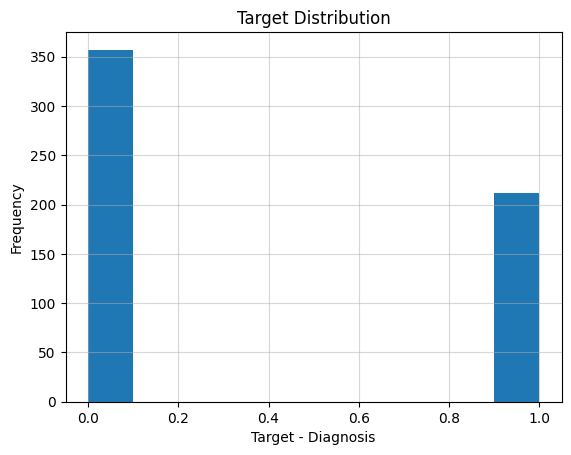

In [22]:
plt.hist(y)
plt.xlabel("Target - Diagnosis")
plt.ylabel("Frequency")
plt.title("Target Distribution")
plt.grid(True, alpha = 0.5)
plt.show()

In [23]:
counts = y.value_counts().sort_index()

malignant = counts[1]
benign = counts[0]

total = malignant + benign

print(f"The number of malignant cases is: {(malignant)}")
print(f"The number of benign cases is: {benign}")
print()
print(f"The percentage of benign cases is: {round((benign *100/total),3) }%")
print(f"The percentage of malignant cases is: {round((malignant *100/total),3) }%")
print()


The number of malignant cases is: 212
The number of benign cases is: 357

The percentage of benign cases is: 62.742%
The percentage of malignant cases is: 37.258%



Due to the uneven distribution in the target, stratified sampling will be needed to ensure that the training and test set have data that is representitive of the split between benign and malignant cases

In [24]:
#train/test split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")




print("y distribution in original:", np.bincount(y))
print("y distribution in train:   ", np.bincount(y_train))
print("y distribution in test:    ", np.bincount(y_test))


X_train shape: (398, 30)
y_train shape: (398,)
X_test shape: (171, 30)
y_test shape: (171,)
y distribution in original: [357 212]
y distribution in train:    [250 148]
y distribution in test:     [107  64]


# Train/Test Split writeup

The dataset was divided into training and test sets with a 70:30 % split. Stratified sampling applied to preserve the original distribution of benign and malignant cases. The original dataset contained 62.74% benign cases and 37.26% malignant cases. Similar proportions were maintained in both training and test sets.



# Exploratory Data Analysis

In [25]:
X_train.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
78,20.18,23.97,143.70,1245.0,0.12860,0.34540,0.37540,0.16040,0.2906,0.08142,...,23.37,31.72,170.30,1623.0,0.1639,0.6164,0.7681,0.2508,0.5440,0.09964
330,16.03,15.51,105.80,793.2,0.09491,0.13710,0.12040,0.07041,0.1782,0.05976,...,18.76,21.98,124.30,1070.0,0.1435,0.4478,0.4956,0.1981,0.3019,0.09124
378,13.66,15.15,88.27,580.6,0.08268,0.07548,0.04249,0.02471,0.1792,0.05897,...,14.54,19.64,97.96,657.0,0.1275,0.3104,0.2569,0.1054,0.3387,0.09638
213,17.42,25.56,114.50,948.0,0.10060,0.11460,0.16820,0.06597,0.1308,0.05866,...,18.07,28.07,120.40,1021.0,0.1243,0.1793,0.2803,0.1099,0.1603,0.06818
89,14.64,15.24,95.77,651.9,0.11320,0.13390,0.09966,0.07064,0.2116,0.06346,...,16.34,18.24,109.40,803.6,0.1277,0.3089,0.2604,0.1397,0.3151,0.08473


In [26]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 398 entries, 78 to 129
Data columns (total 30 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              398 non-null    float64
 1   mean texture             398 non-null    float64
 2   mean perimeter           398 non-null    float64
 3   mean area                398 non-null    float64
 4   mean smoothness          398 non-null    float64
 5   mean compactness         398 non-null    float64
 6   mean concavity           398 non-null    float64
 7   mean concave points      398 non-null    float64
 8   mean symmetry            398 non-null    float64
 9   mean fractal dimension   398 non-null    float64
 10  radius error             398 non-null    float64
 11  texture error            398 non-null    float64
 12  perimeter error          398 non-null    float64
 13  area error               398 non-null    float64
 14  smoothness error         398 n

In [27]:
y_train.head()

,target
78,1
330,1
378,0
213,1
89,0


In [28]:
corr_matrix = X_train.corr()


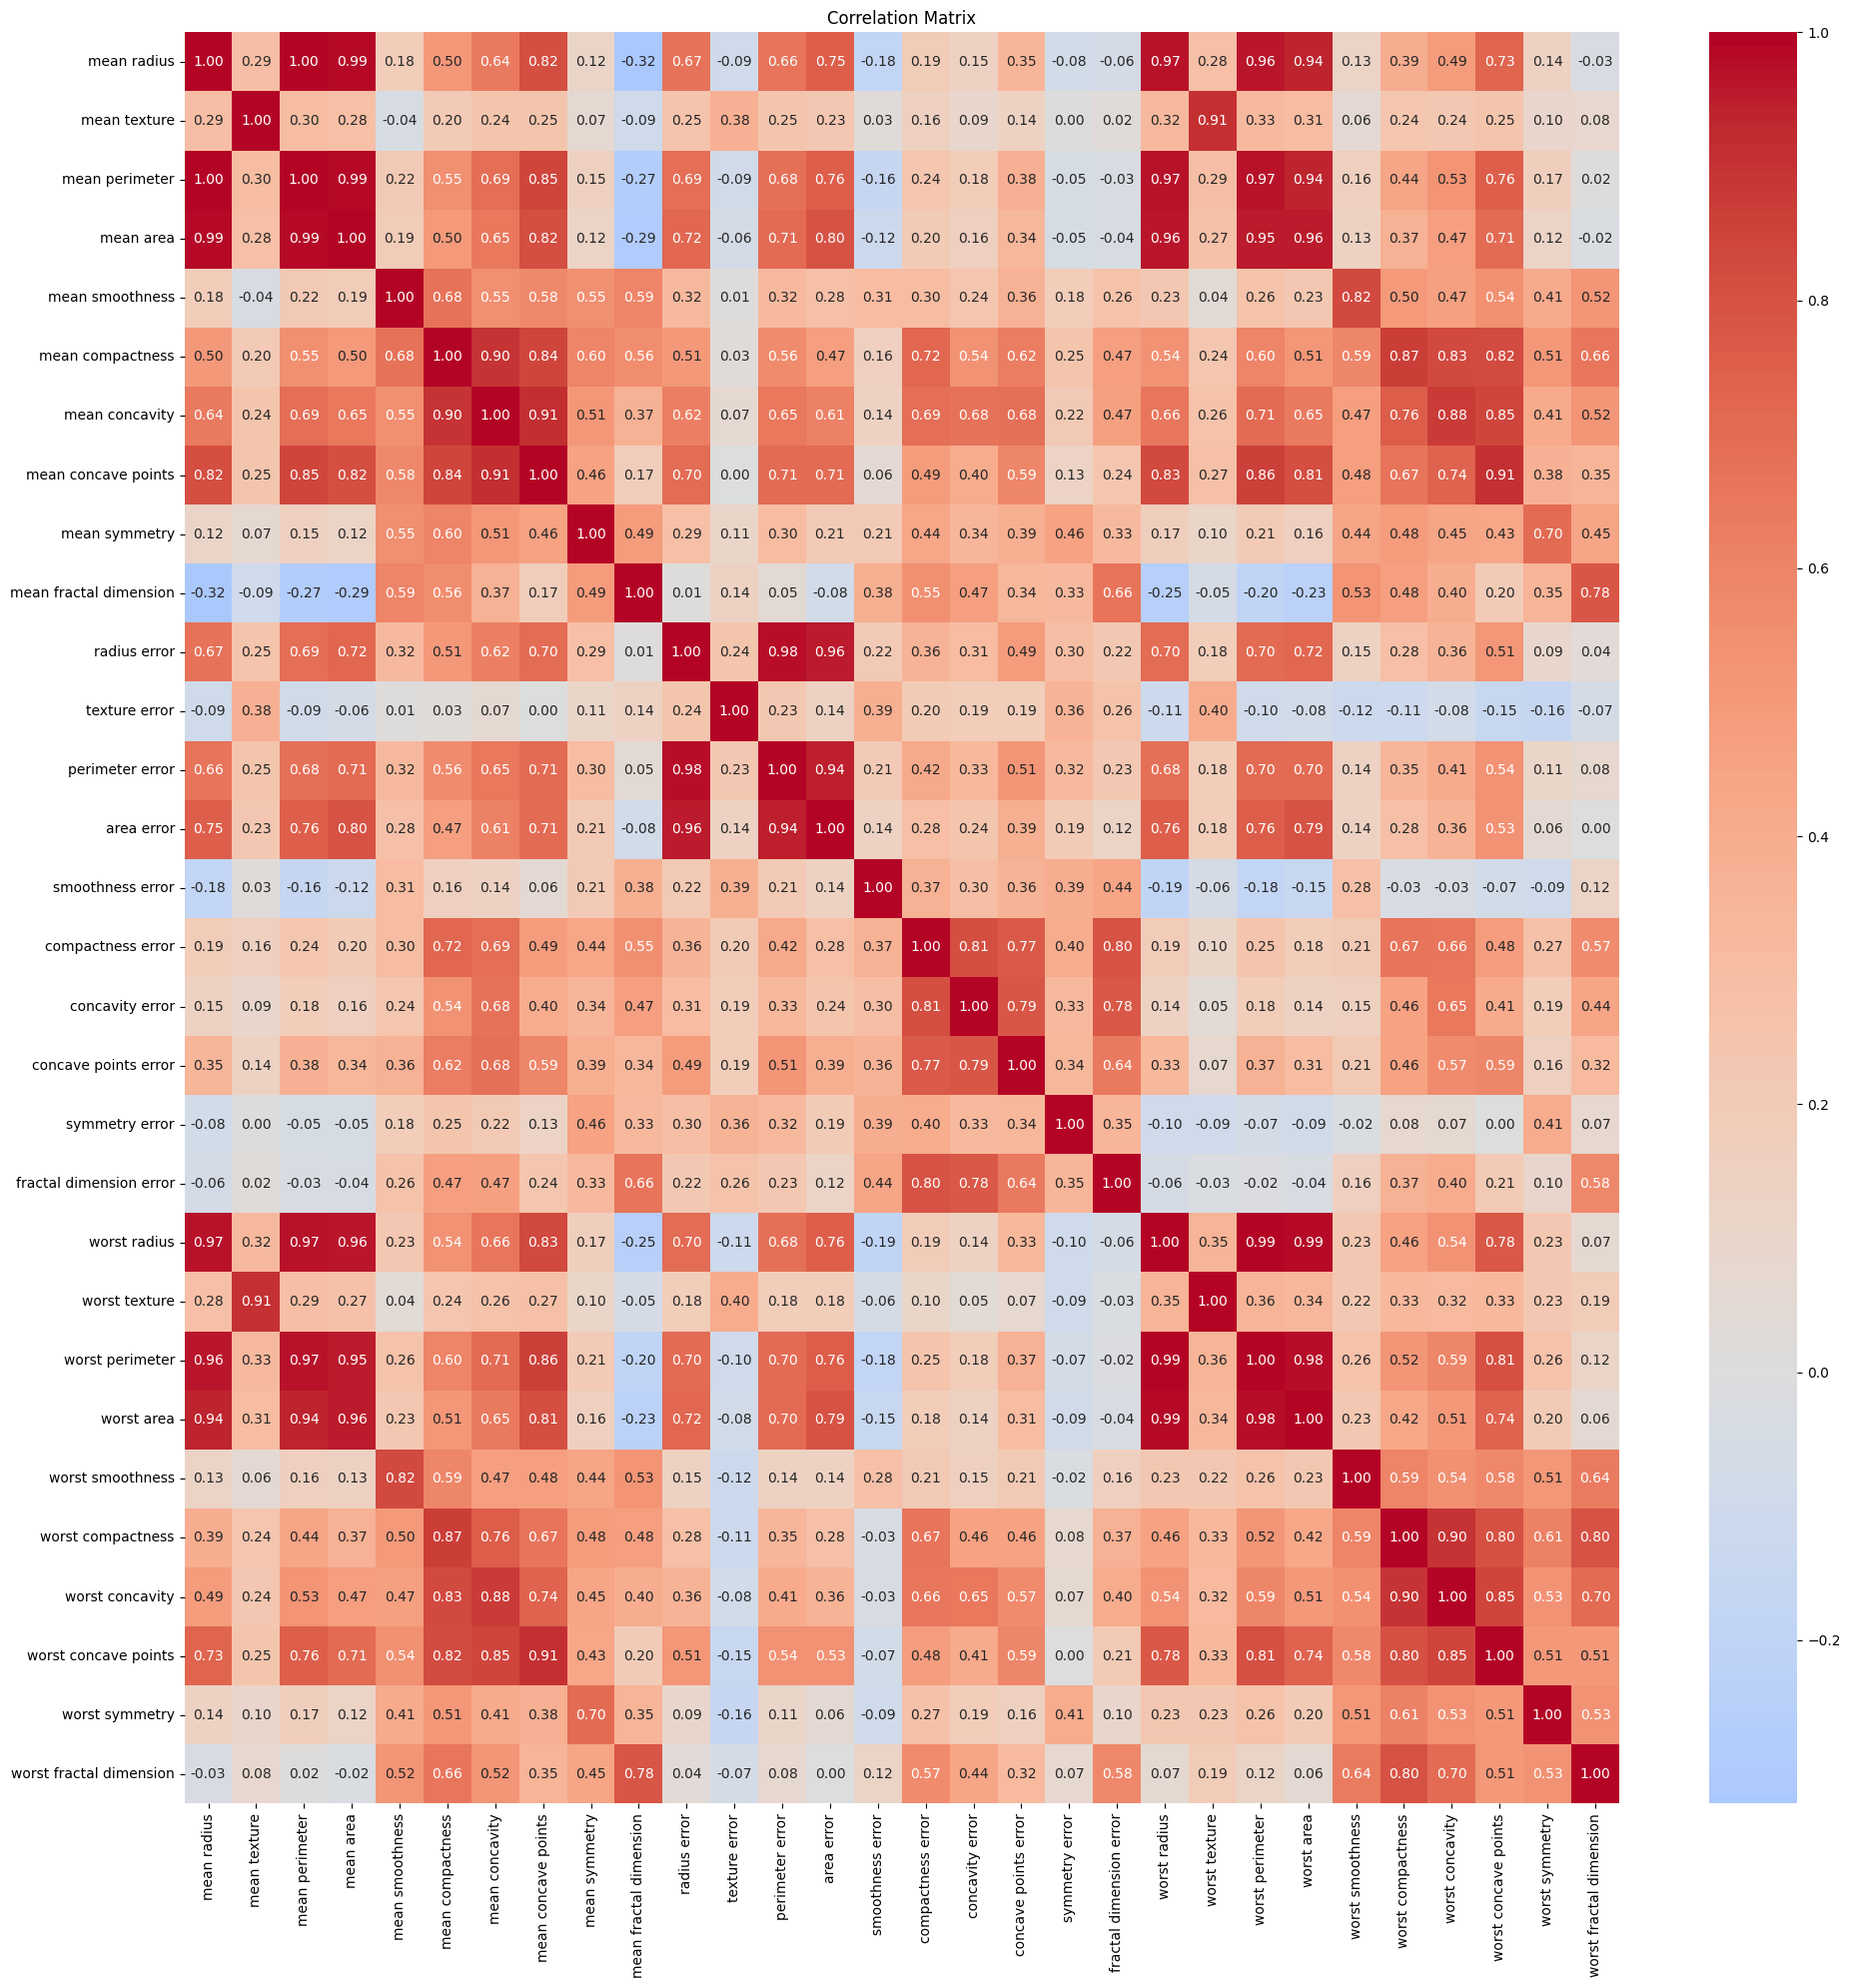

In [29]:
plt.figure(figsize=(20, 20))
sns.heatmap(corr_matrix,
            annot=True,
            cmap='coolwarm',
            fmt=".2f",
            center = 0
            )


plt.xticks(rotation = 90, fontsize = 10)
plt.yticks(rotation = 0, fontsize = 10)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

In [30]:
train_df = X_train.copy()
train_df["target"] = y_train

train_corr = train_df.corr()

target_corr = (train_corr["target"].drop("target").sort_values(ascending = False))

In [31]:
target_corr

,target
worst perimeter,0.781133
worst concave points,0.779404
worst radius,0.774868
mean concave points,0.767937
worst area,0.737012
mean perimeter,0.735620
mean radius,0.722837
mean area,0.703440
mean concavity,0.664965
worst concavity,0.625757


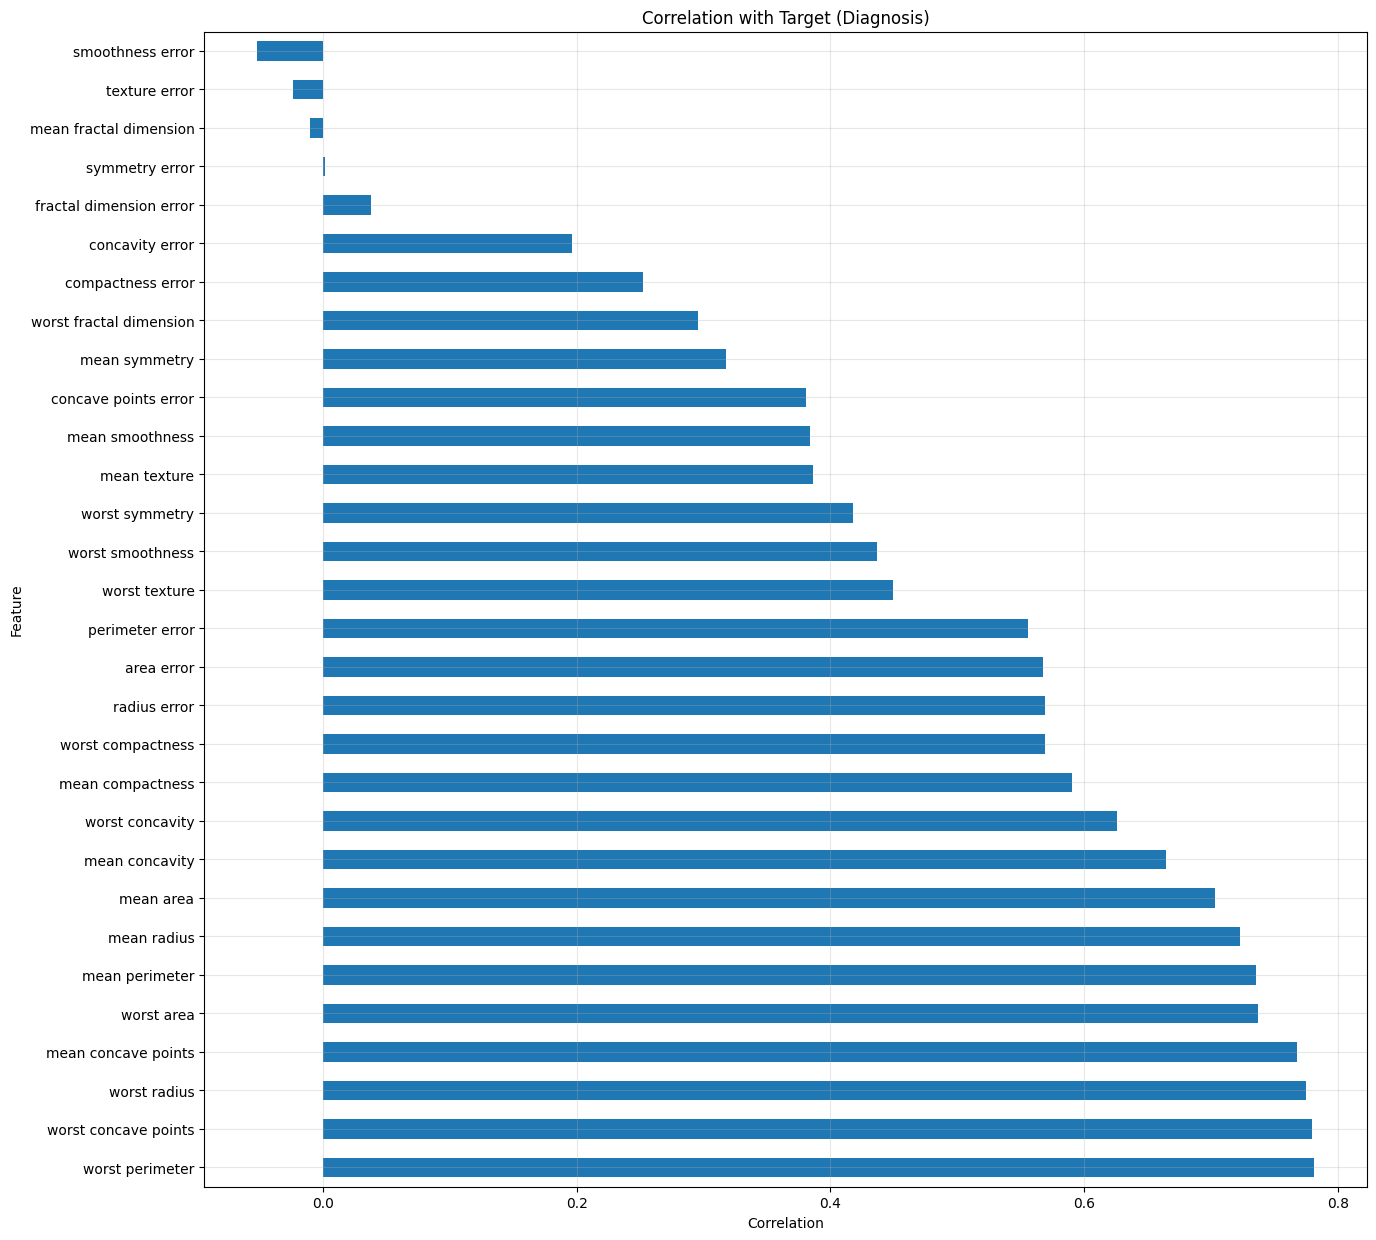

In [32]:
target_corr.plot(kind = "barh", figsize = (15,15))

plt.title("Correlation with Target (Diagnosis)")
plt.xlabel("Correlation")
plt.ylabel("Feature")
plt.grid(True, alpha = 0.3)
plt.show()

In [33]:
def get_strong_feature_correlations(data_frame, correlation_threshold):

  """
  Finding strongly correlated features within a dataframe
  Fo

  """

  if correlation_threshold < 0 or correlation_threshold > 1:
    raise ValueError("Threshold must be between 0 and 1")


  final_dictionary = {}

  corr_matrix = data_frame.corr()

  for i in corr_matrix:


    feature_corr = corr_matrix.loc[i].drop(i)

    strong_features = feature_corr.abs() >= correlation_threshold

    strong_corr = feature_corr[strong_features]
    strong_sorted = strong_corr.abs().sort_values(ascending = False).index

    if not strong_sorted.empty:
      final_dictionary[i] = feature_corr[strong_sorted]




  return final_dictionary




strong_corrs = get_strong_feature_correlations(X_train, correlation_threshold = 0.65)

In [37]:
strong_corrs

{'mean radius': mean perimeter          0.997743
 mean area               0.988068
 worst radius            0.968609
 worst perimeter         0.962247
 worst area              0.942030
 mean concave points     0.815090
 area error              0.748016
 worst concave points    0.727245
 radius error            0.672830
 perimeter error         0.664796
 Name: mean radius, dtype: float64,
 'mean texture': worst texture    0.910633
 Name: mean texture, dtype: float64,
 'mean perimeter': mean radius             0.997743
 mean area               0.986890
 worst radius            0.969029
 worst perimeter         0.968457
 worst area              0.942474
 mean concave points     0.845341
 area error              0.757233
 worst concave points    0.755873
 radius error            0.686410
 mean concavity          0.686151
 perimeter error         0.684646
 Name: mean perimeter, dtype: float64,
 'mean area': mean radius             0.988068
 mean perimeter          0.986890
 worst radius    

# Exploratory Data Analysis - WriteUp

### Heatmap
(Anything over 0.6)

  strong_corr is a dict that returned the strongest features (i.e. correalations equal to or above 0.65)


##  Distributions

# **Workflow I Am Following**

## 1. Project Overview

## 2. Project Objectives

## 3. Dataset Source and Description

## 4. Import Libraries

## 5. Load the Dataset

## 6. Combine Features and Target into One DataFrame

## 7. Rename Columns for Readability

## 8. Initial Data Inspection

### 8.1 View First Rows

### 8.2 Dataset Shape

### 8.3 Data Types and Non-Null Counts

### 8.4 Summary Statistics

### 8.5 Missing Values

### 8.6 Duplicate Rows

## 9. Initial Observations

## 10. Train/Test Split

### 10.1 Separate Features and Target

### 10.2 Create Stratified Training and Test Sets

### 10.3 Confirm Dataset Shapes

### 10.4 Confirm Class Proportions Are Preserved

## 11. Exploratory Data Analysis on Training Set Only

### 11.1 Target Distribution

### 11.2 Feature Distributions

### 11.3 Feature Group Analysis

### 11.4 Correlation Analysis

### 11.5 Malignant vs Benign Feature Comparisons

### 11.6 Selected Pairwise Feature Relationships

### 11.7 EDA Summary

## 12. Feature Engineering / Feature Selection

### 12.1 Check Feature Scaling Requirements

### 12.2 Check Highly Correlated Features

### 12.3 Optional: Remove or Compare Redundant Features

### 12.4 Optional: Feature Selection Using Model-Based Importance

### 12.5 Feature Engineering / Selection Summary

## 13. Preprocessing Pipeline

### 13.1 Numerical Feature Pipeline

### 13.2 Full Preprocessing Pipeline

### 13.3 Why Preprocessing Is Inside the Model Pipeline

## 14. Baseline Models

### 14.1 Majority-Class Baseline

### 14.2 Simple Logistic Regression Baseline

### 14.3 Baseline Model Comparison

### 14.4 Baseline Summary

## 15. Linear / Statistical Classification Models

### 15.1 Logistic Regression

### 15.2 SGD Classifier

### 15.3 Optional: Regularised Logistic Regression

### 15.4 Linear Model Comparison

### 15.5 Linear Model Summary

## 16. Machine Learning Classification Models

### 16.1 K-Nearest Neighbours Classifier

### 16.2 Support Vector Machine Classifier

### 16.3 Decision Tree Classifier

### 16.4 Random Forest Classifier

### 16.5 Optional: Gradient Boosting Classifier

### 16.6 Machine Learning Model Comparison

### 16.7 Machine Learning Model Summary

## 17. Overall Model Comparison

### 17.1 Accuracy Comparison

### 17.2 Precision Comparison

### 17.3 Recall Comparison

### 17.4 F1-Score Comparison

### 17.5 ROC-AUC Comparison

### 17.6 Overfitting and Underfitting Discussion

### 17.7 Best Model Selection

## 18. Hyperparameter Tuning

### 18.1 Randomized Search or Grid Search Setup

### 18.2 Best Hyperparameters

### 18.3 Best Cross-Validation Score

### 18.4 Tuned vs Untuned Model Comparison

### 18.5 Hyperparameter Tuning Summary

## 19. Final Test Set Evaluation

### 19.1 Generate Final Predictions

### 19.2 Accuracy

### 19.3 Precision

### 19.4 Recall

### 19.5 F1-Score

### 19.6 Confusion Matrix

### 19.7 ROC Curve and ROC-AUC

### 19.8 Test Evaluation Summary

## 20. Feature Importance / Model Interpretation

### 20.1 Extract Feature Importances or Coefficients

### 20.2 Create Feature Importance Table

### 20.3 Plot Top Features

### 20.4 Feature Importance Interpretation

## 21. Classification Error Analysis

### 21.1 Create Results DataFrame

### 21.2 Confusion Matrix Interpretation

### 21.3 False Positive Analysis

### 21.4 False Negative Analysis

### 21.5 Probability Score Analysis

### 21.6 Largest / Most Confident Misclassifications

### 21.7 Error Analysis Summary

## 22. Threshold Analysis

### 22.1 Predicted Probability Scores

### 22.2 Precision-Recall Trade-Off

### 22.3 Threshold Selection Discussion

### 22.4 Medical Interpretation of False Negatives

### 22.5 Threshold Analysis Summary

## 23. Optional Confidence Interval Analysis

### 23.1 Confidence Interval for Accuracy

### 23.2 Optional: Confidence Interval for Recall

### 23.3 Interpret Model Uncertainty

## 24. Export Results for Power BI

### 24.1 Export Prediction Results

### 24.2 Export Model Comparison Table

### 24.3 Export Feature Importance Table

### 24.4 Export Cleaned Dataset if Needed

## 25. Power BI Dashboard Plan

### 25.1 Dashboard Page 1: Dataset Overview

### 25.2 Dashboard Page 2: Model Performance

### 25.3 Dashboard Page 3: Error Analysis

### 25.4 Dashboard Visuals Checklist

## 26. Final Project Conclusion

### 26.1 Summary of Workflow

### 26.2 Best Performing Model

### 26.3 Key Features

### 26.4 Main Error Patterns

### 26.5 Threshold Analysis Findings

### 26.6 Limitations

### 26.7 Future Improvements

## 27. References

## 28. Appendix / Extra Experiments
